# LangGraph Agent
## Without tools

## Library Imports

In [2]:
from langchain_core.messages import HumanMessage
from langchain_anthropic import ChatAnthropic
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, MessagesState
import logging
from IPython.display import Image, Markdown, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

/usr/local/python/3.12.1/lib/python3.12/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## Configure logging

In [3]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    filename='langgraph_notebook.log',
    level=logging.INFO,
)

## Configure Agent and Model

In [7]:
model = ChatAnthropic(model='claude-sonnet-4-6', temperature=0)

def call_model(state: MessagesState):
    messages = state['messages']
    response = model.invoke(messages)
    return {"messages": [response]}

workflow = StateGraph(MessagesState)
workflow.add_node("agent", call_model)
workflow.add_edge(START, "agent")
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)


## Visualize the Graph

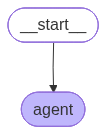

In [8]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method = MermaidDrawMethod.API
        )
    )
)

## Chat with the Agent

In [9]:
final_state = app.invoke(
    {"messages":[HumanMessage(content = "What teams did Joe Montana play for?")]},
    config = {"configurable":{"thread_id":99}}
)
display(Markdown(final_state["messages"][-1].content))

Joe Montana played for the following NFL teams:

- **San Francisco 49ers** (1979–1992) – where he had the majority of his career and won four Super Bowls
- **Kansas City Chiefs** (1993–1994) – where he finished his career

In [10]:
final_state = app.invoke(
    {"messages":[HumanMessage(content = "What are the leagues in the SportsWorldCentral fantasy football platform?")]},
    config = {"configurable":{"thread_id":99}}
)
display(Markdown(final_state["messages"][-1].content))

I don't have specific information about the SportsWorldCentral fantasy football platform or the leagues it offers. I'd recommend visiting their website directly or contacting their support team to get accurate and up-to-date details about their available leagues.